# Iris Multivariate Analysis — Unit II: Univariate, Bivariate, and Multivariate Analysis

## Day 1: Univariate Analysis — Frequency Tables, Histograms, Density Plots, Boxplots, Violin Plots

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/iris.csv")
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
freq_table = df["species"].value_counts().reset_index()
freq_table.columns = ["Species", "Absolute_Frequency"]
freq_table["Relative_Frequency"] = (freq_table["Absolute_Frequency"] / len(df)).round(3)
freq_table["Cumulative_Frequency"] = freq_table["Absolute_Frequency"].cumsum()
freq_table

,Species,Absolute_Frequency,Relative_Frequency,Cumulative_Frequency
0,setosa,50,0.333,50
1,versicolor,50,0.333,100
2,virginica,50,0.333,150


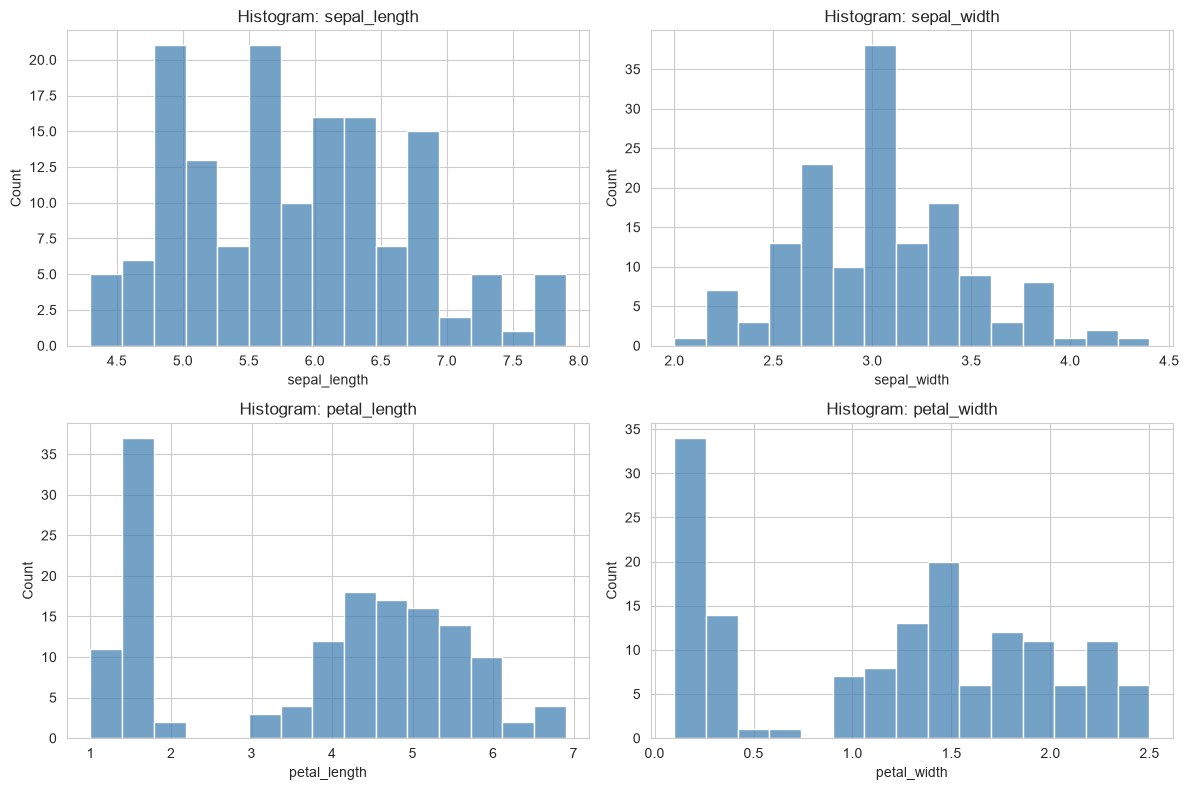

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=15, kde=False, ax=ax, color="steelblue")
    ax.set_title(f"Histogram: {col}")
plt.tight_layout()
plt.savefig("../outputs/day1_histograms.png", dpi=120)
plt.show()

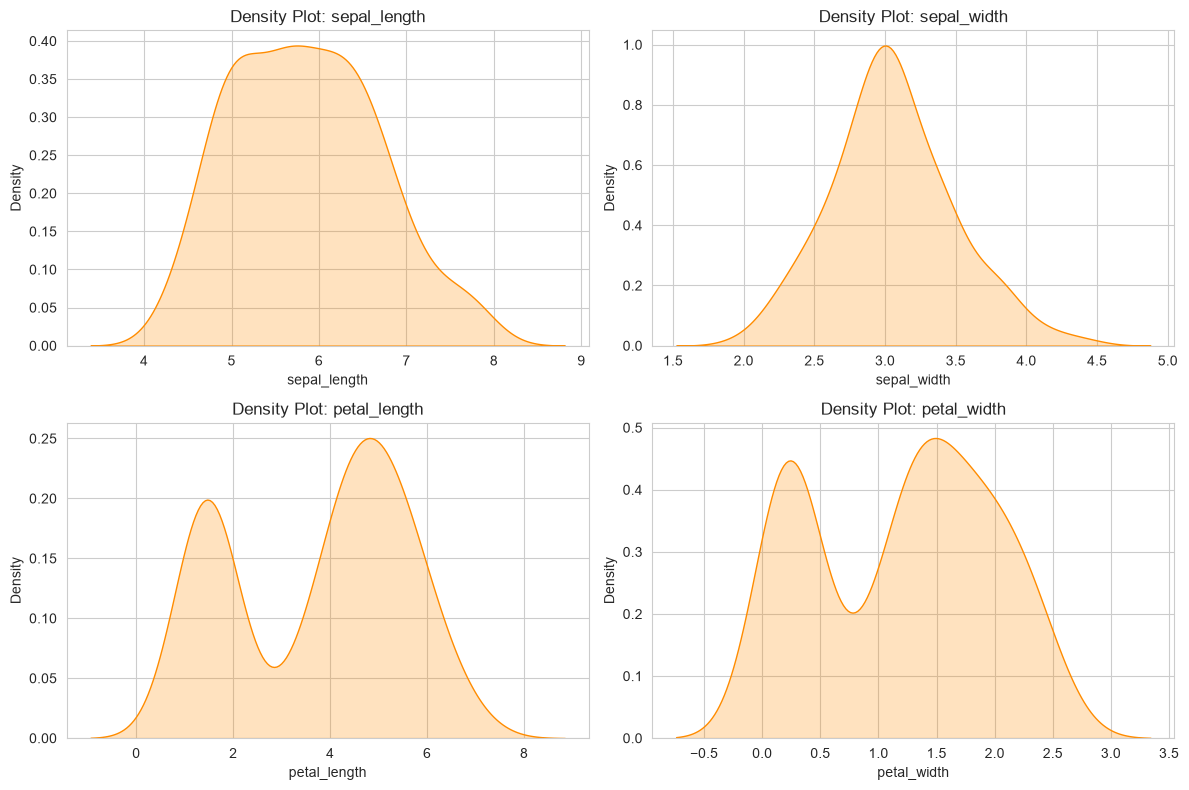

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(df[col], ax=ax, fill=True, color="darkorange")
    ax.set_title(f"Density Plot: {col}")
plt.tight_layout()
plt.savefig("../outputs/day1_density_plots.png", dpi=120)
plt.show()

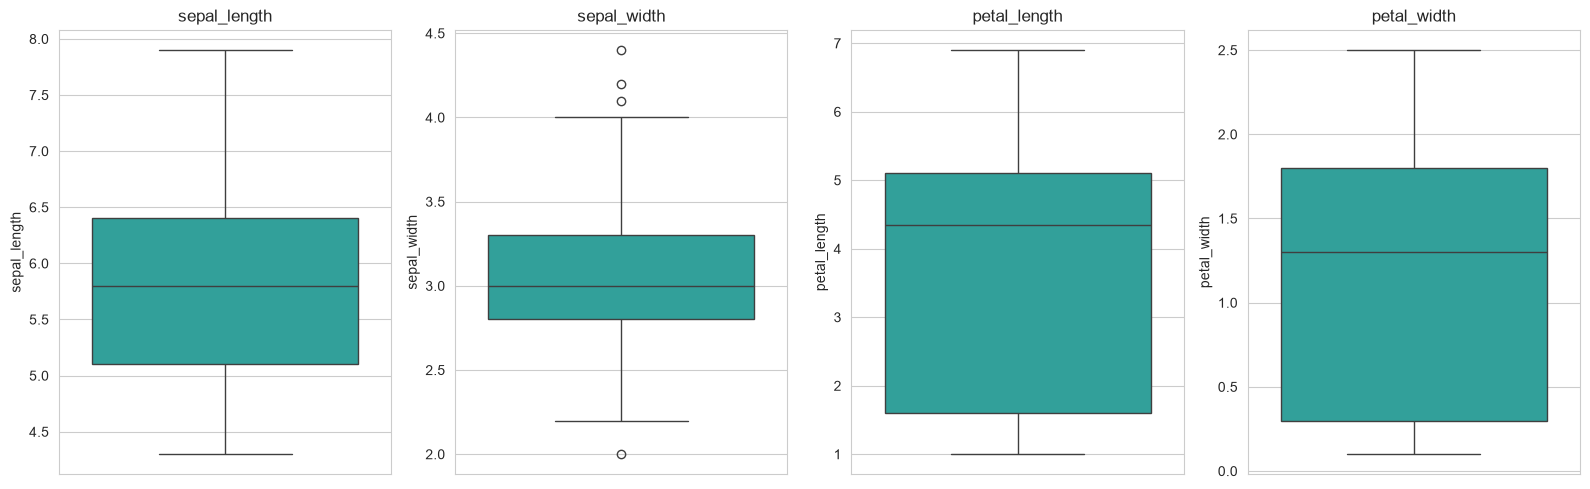

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/day1_boxplots.png", dpi=120)
plt.show()

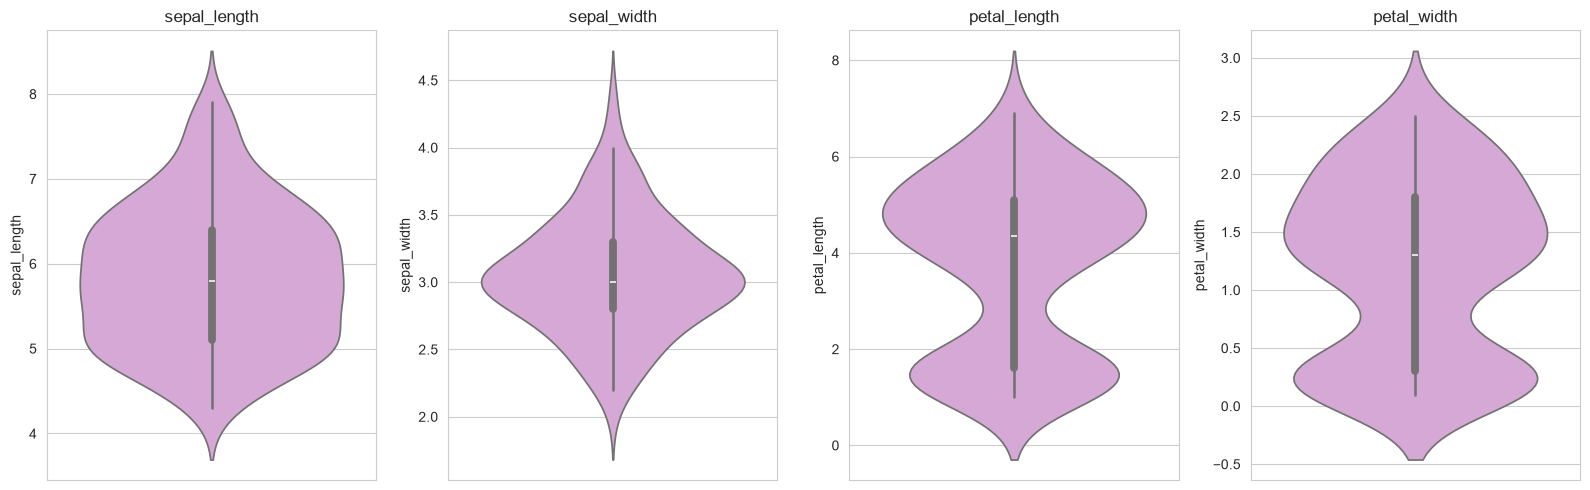

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, numeric_cols):
    sns.violinplot(y=df[col], ax=ax, color="plum")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/day1_violin_plots.png", dpi=120)
plt.show()

**Observation:** Histograms and density plots show the actual shape of each
variable's distribution (petal measurements appear bimodal — a cluster from
setosa, separated from versicolor/virginica). Boxplots summarize spread and
outliers compactly but hide this bimodal shape; violin plots recover it while
still marking the median, illustrating why shape-sensitive visuals matter
alongside boxplots.

## Day 2: Bivariate Analysis — Scatter Plots, Grouped Bar Plots, Covariance, Correlation

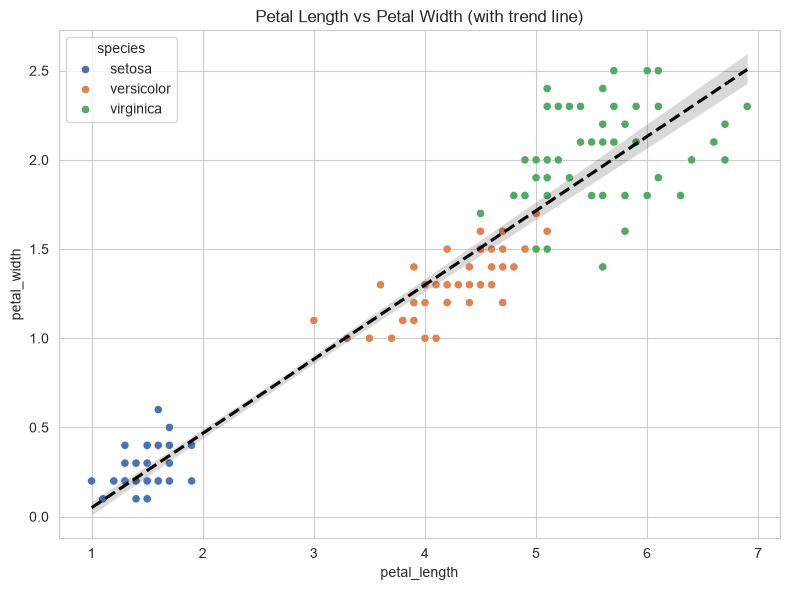

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", palette="deep")
sns.regplot(data=df, x="petal_length", y="petal_width", scatter=False, color="black", line_kws={"linestyle": "--"})
plt.title("Petal Length vs Petal Width (with trend line)")
plt.tight_layout()
plt.savefig("../outputs/day2_scatter_petal.png", dpi=120)
plt.show()

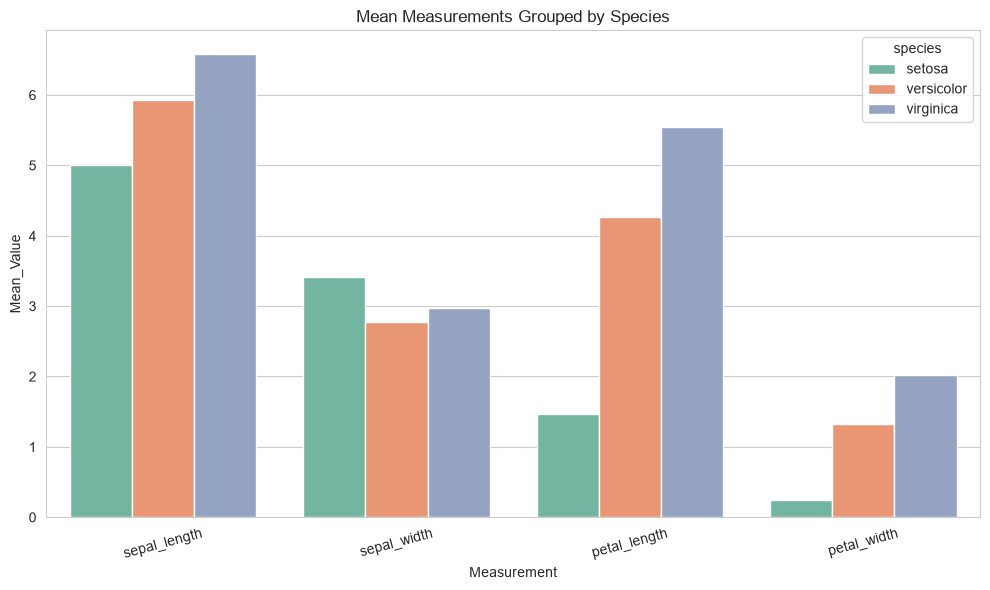

In [27]:
species_means = df.groupby("species")[numeric_cols].mean().reset_index()
species_means_melted = species_means.melt(id_vars="species", var_name="Measurement", value_name="Mean_Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=species_means_melted, x="Measurement", y="Mean_Value", hue="species", palette="Set2")
plt.title("Mean Measurements Grouped by Species")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/day2_grouped_bar.png", dpi=120)
plt.show()

In [28]:
cov_matrix = df[numeric_cols].cov()
cov_matrix.round(2)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.69,-0.04,1.27,0.52
sepal_width,-0.04,0.19,-0.32,-0.12
petal_length,1.27,-0.32,3.11,1.30
petal_width,0.52,-0.12,1.30,0.58


In [29]:
corr_matrix = df[numeric_cols].corr()
corr_matrix.round(2)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.11,0.87,0.82
sepal_width,-0.11,1.00,-0.42,-0.36
petal_length,0.87,-0.42,1.00,0.96
petal_width,0.82,-0.36,0.96,1.00


**Observation:** Covariance values are hard to compare directly since they
depend on the units/scale of each variable (e.g., cm² here). Correlation
standardizes this into a unit-free measure between -1 and 1 — we can see
petal_length and petal_width are very strongly positively correlated
(~0.96), while sepal_width has weak/negative correlation with the others.

## Day 3: Multivariate Analysis — Heatmaps, Scatter Matrix, Pair Plots, Trends & Clusters

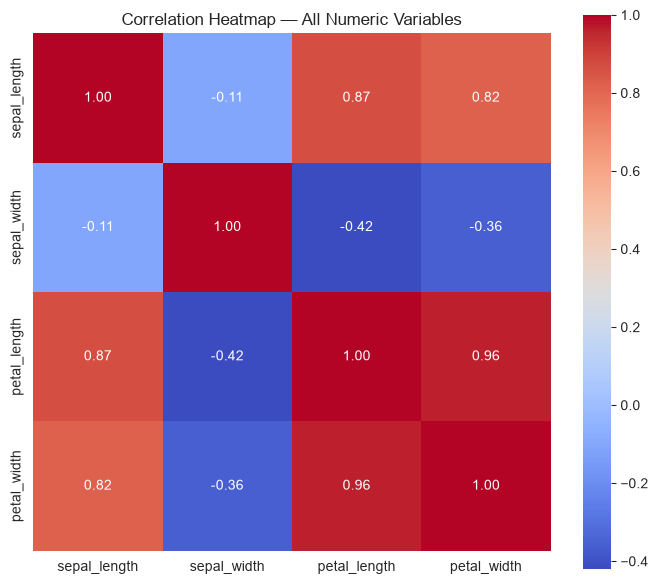

In [30]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap — All Numeric Variables")
plt.tight_layout()
plt.savefig("../outputs/day3_heatmap.png", dpi=120)
plt.show()

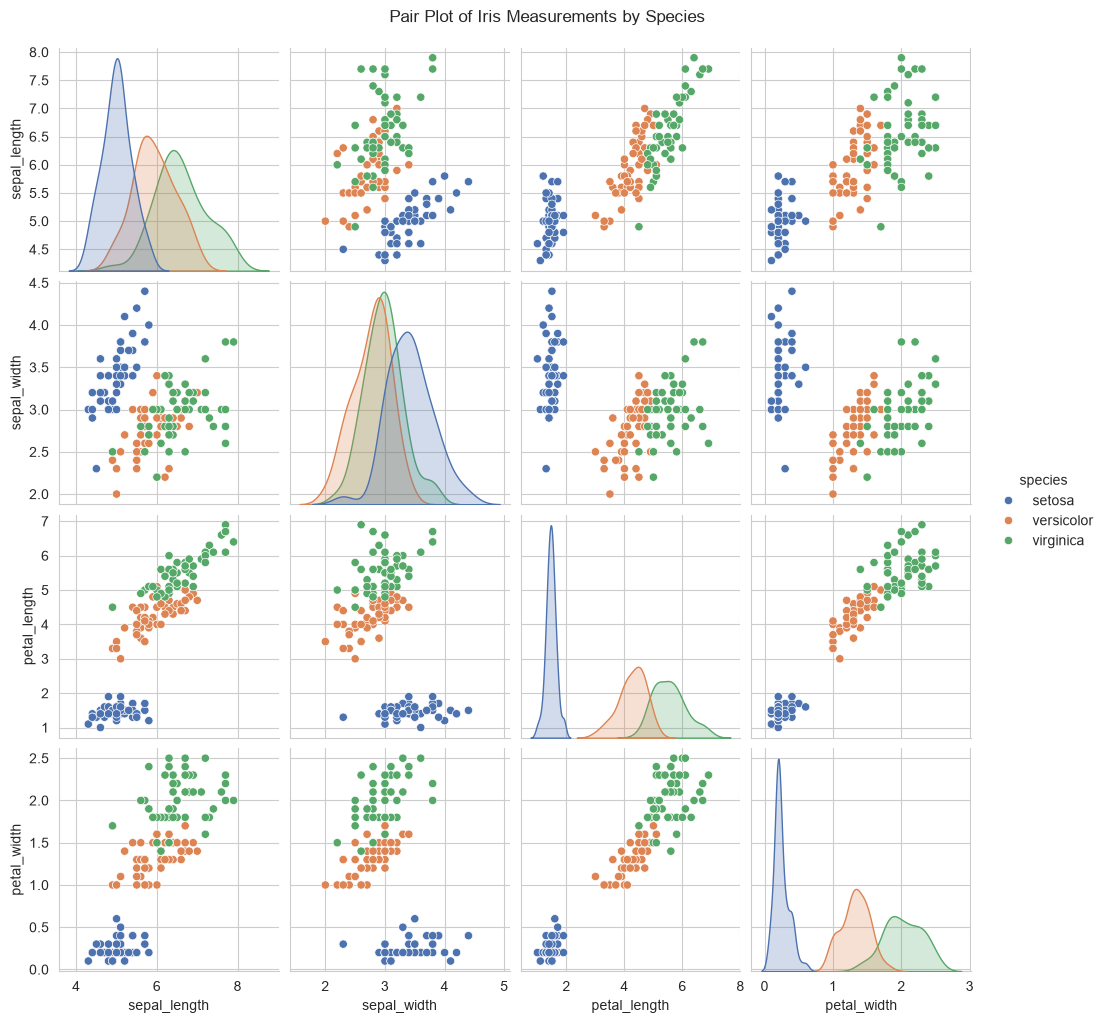

In [31]:
pairplot_fig = sns.pairplot(df, hue="species", vars=numeric_cols, palette="deep", diag_kind="kde")
pairplot_fig.fig.suptitle("Pair Plot of Iris Measurements by Species", y=1.02)
pairplot_fig.savefig("../outputs/day3_pairplot.png", dpi=120)
plt.show()

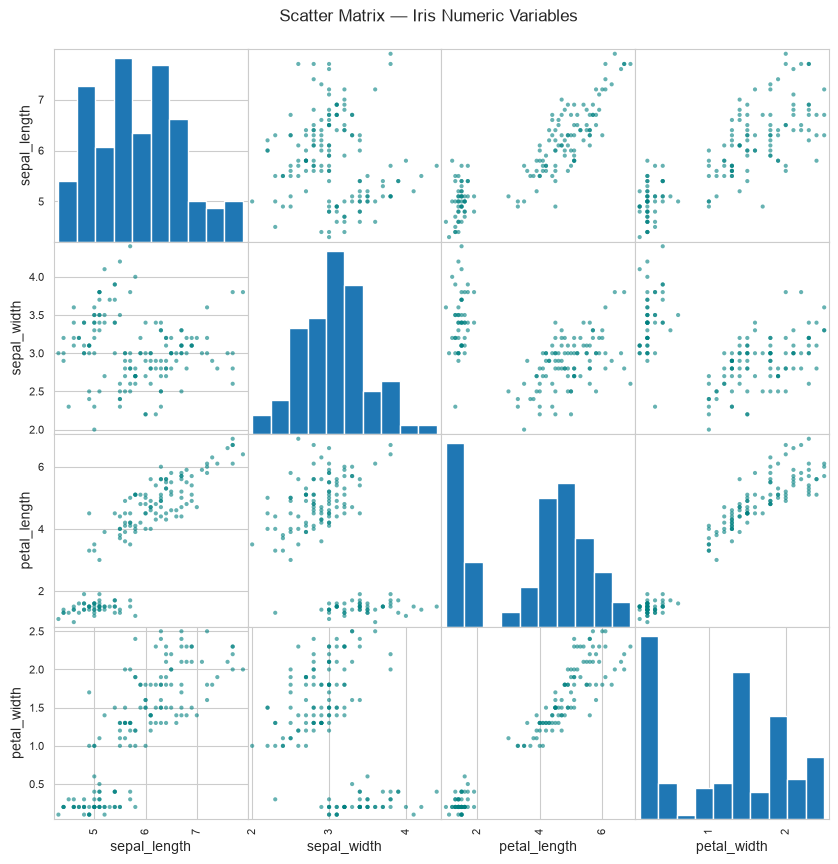

In [32]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[numeric_cols], figsize=(10, 10), diagonal="hist", color="teal", alpha=0.6)
plt.suptitle("Scatter Matrix — Iris Numeric Variables", y=0.92)
plt.savefig("../outputs/day3_scatter_matrix.png", dpi=120)
plt.show()

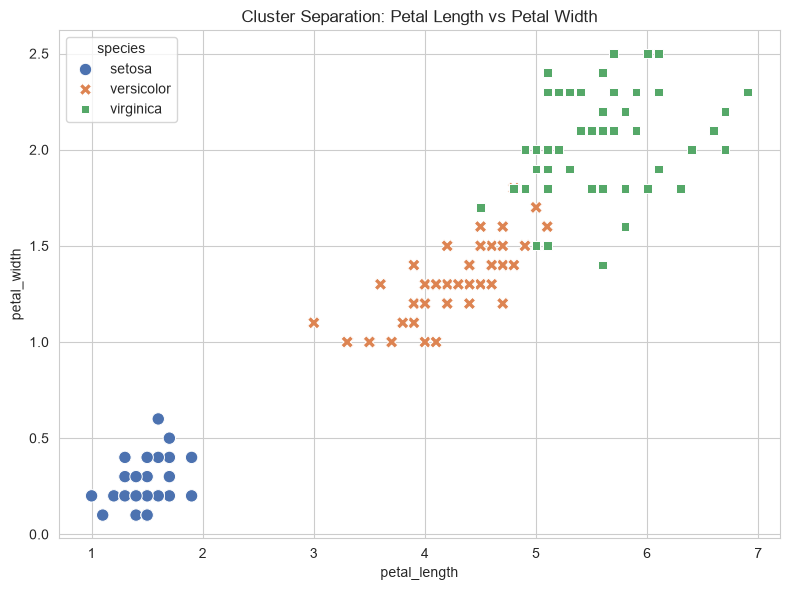

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", style="species", s=80, palette="deep")
plt.title("Cluster Separation: Petal Length vs Petal Width")
plt.tight_layout()
plt.savefig("../outputs/day3_cluster_view.png", dpi=120)
plt.show()

**Observation:** The heatmap confirms petal_length and petal_width are the
most strongly correlated pair (~0.96). The pair plot and scatter matrix
reveal that setosa forms a completely separate, tight cluster across nearly
every variable pair, while versicolor and virginica overlap more, especially
on sepal measurements — but remain reasonably distinguishable using petal
length/width. This kind of visual cluster separation is exactly what
multivariate analysis is meant to surface before applying any formal
clustering or classification algorithm.

## Day 4: Dimensionality Reduction — Principal Component Analysis (PCA)

In [34]:
from sklearn.preprocessing import StandardScaler

X = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(2))
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(2))

Mean after scaling (should be ~0): [-0. -0.  0. -0.]
Std after scaling (should be ~1): [1. 1. 1. 1.]


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2", "PC3", "PC4"])
pca_df["species"] = df["species"].values
pca_df.head()

,PC1,PC2,PC3,PC4,species
0,-2.264542,0.505704,0.121943,-0.023073,setosa
1,-2.086426,-0.655405,0.227251,-0.103208,setosa
2,-2.367950,-0.318477,-0.051480,-0.027825,setosa
3,-2.304197,-0.575368,-0.098860,0.066311,setosa
4,-2.388777,0.674767,-0.021428,0.037397,setosa


In [36]:
explained_var = pca.explained_variance_ratio_ * 100
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.2f}% of variance explained")
print(f"\nPC1 + PC2 combined: {explained_var[0] + explained_var[1]:.2f}% of total variance")

PC1: 72.77% of variance explained
PC2: 23.03% of variance explained
PC3: 3.68% of variance explained
PC4: 0.52% of variance explained

PC1 + PC2 combined: 95.80% of total variance


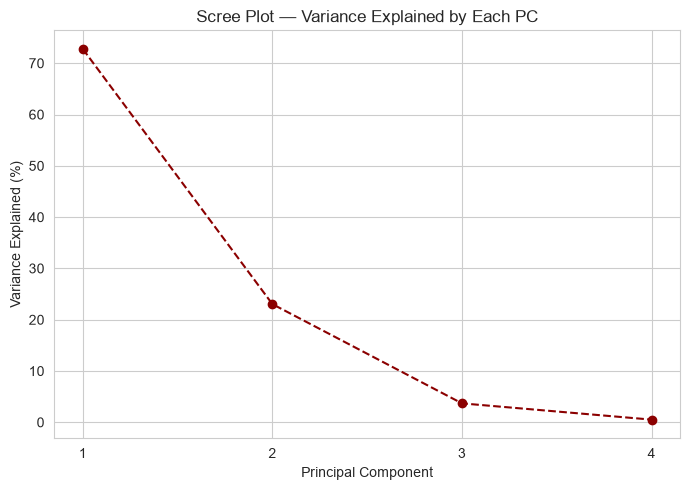

In [37]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, 5), explained_var, marker="o", linestyle="--", color="darkred")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot — Variance Explained by Each PC")
plt.xticks(range(1, 5))
plt.tight_layout()
plt.savefig("../outputs/day4_scree_plot.png", dpi=120)
plt.show()

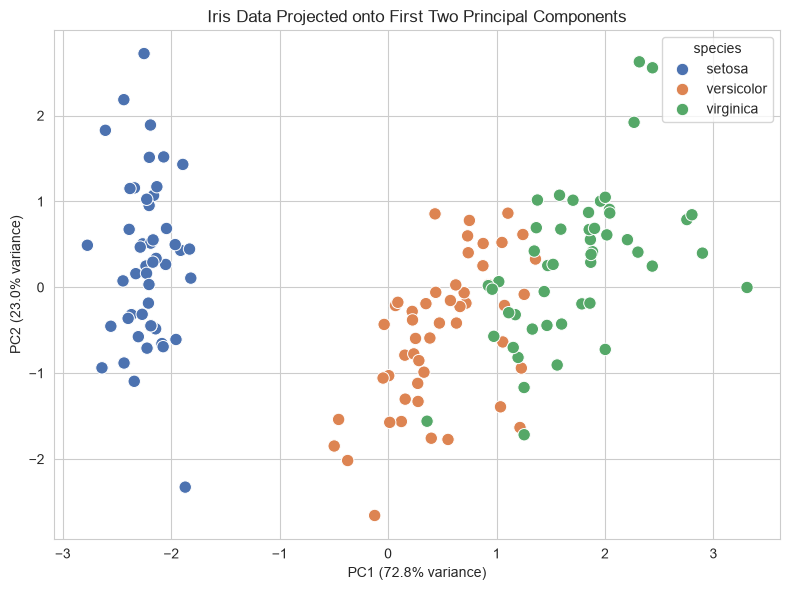

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", palette="deep", s=80)
plt.title("Iris Data Projected onto First Two Principal Components")
plt.xlabel(f"PC1 ({explained_var[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]:.1f}% variance)")
plt.tight_layout()
plt.savefig("../outputs/day4_pca_scatter.png", dpi=120)
plt.show()

**Observation:** PC1 alone captures the majority of the variance in the
dataset, and PC1 + PC2 together capture well over 95%. This means the
4-dimensional Iris data can be represented in just 2 dimensions with very
little information loss. The PC1 vs PC2 scatter plot still shows setosa
clearly separated, with versicolor and virginica showing some overlap —
consistent with what we observed in the original pair plots, confirming
PCA preserved the meaningful structure of the data while reducing
dimensionality.

## Day 5: Feature Selection & Multicollinearity Detection

In [40]:
corr_matrix = df[numeric_cols].corr().abs()
print("Correlation matrix (absolute values):")
print(corr_matrix.round(2))

# Flag highly correlated pairs (potential redundancy)
threshold = 0.9
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        if corr_matrix.iloc[i, j] > threshold:
            high_corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_matrix.iloc[i, j]))

print(f"\nHighly correlated pairs (>{threshold}):")
for pair in high_corr_pairs:
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.2f}")

Correlation matrix (absolute values):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00         0.11          0.87         0.82
sepal_width           0.11         1.00          0.42         0.36
petal_length          0.87         0.42          1.00         0.96
petal_width           0.82         0.36          0.96         1.00

Highly correlated pairs (>0.9):
  petal_length <-> petal_width: 0.96


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[numeric_cols]
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(numeric_cols))]
vif_data.round(2)

,Feature,VIF
0,sepal_length,264.75
1,sepal_width,97.11
2,petal_length,173.97
3,petal_width,55.49


C:\Users\D.NIKITHA\AppData\Local\Temp\ipykernel_22992\2707985548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_data, x="Feature", y="VIF", palette="rocket")


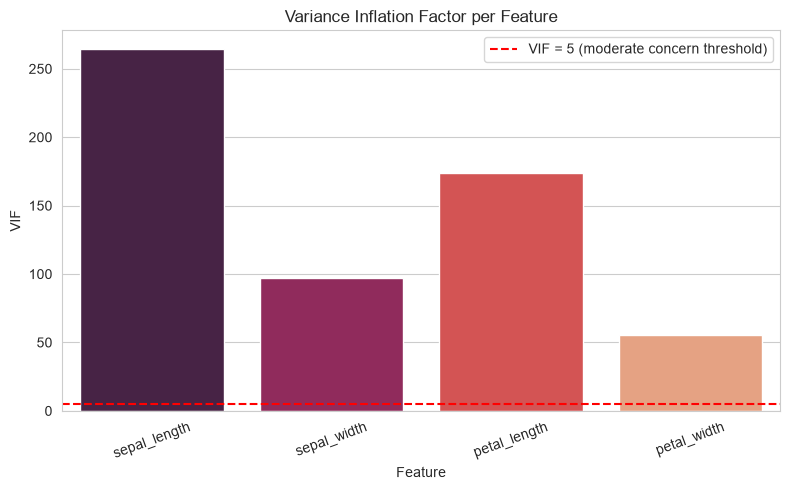

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(data=vif_data, x="Feature", y="VIF", palette="rocket")
plt.axhline(y=5, color="red", linestyle="--", label="VIF = 5 (moderate concern threshold)")
plt.title("Variance Inflation Factor per Feature")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/day5_vif_chart.png", dpi=120)
plt.show()

In [43]:
feature_variance = df[numeric_cols].var().sort_values(ascending=False)
print("Feature variance (higher = more information carried):")
print(feature_variance.round(2))

print("""
Feature selection reasoning:
- petal_length and petal_width are highly correlated with each other AND
  with sepal_length -> some redundancy exists between them.
- If VIF for any feature exceeds 10, consider dropping it or combining
  it with PCA components (from Day 4) instead of using raw features.
- sepal_width tends to carry the most independent information (lowest
  correlation with the rest), making it a good candidate to always keep.
""")

Feature variance (higher = more information carried):
petal_length    3.11
sepal_length    0.69
petal_width     0.58
sepal_width     0.19
dtype: float64

Feature selection reasoning:
- petal_length and petal_width are highly correlated with each other AND
  with sepal_length -> some redundancy exists between them.
- If VIF for any feature exceeds 10, consider dropping it or combining
  it with PCA components (from Day 4) instead of using raw features.
- sepal_width tends to carry the most independent information (lowest
  correlation with the rest), making it a good candidate to always keep.



**Observation:** petal_length and petal_width show very high correlation
(~0.96) and elevated VIF values, indicating strong multicollinearity between
them — much of the information in one is already captured by the other. In
a real modeling scenario, this would suggest either (a) dropping one of the
two, (b) combining correlated features via PCA (as done in Day 4), or
(c) using a regularized model (e.g., Ridge regression) that handles
multicollinearity gracefully. sepal_width, being the least correlated
feature, contributes more unique/independent information and is a strong
candidate to retain regardless of the approach chosen.

## Day 6: Data Transformation & Final Summary

In [44]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)
print("Min-Max scaled data (range 0 to 1):")
df_minmax.describe().round(2)

Min-Max scaled data (range 0 to 1):


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,0.43,0.44,0.47,0.46
std,0.23,0.18,0.30,0.32
min,0.00,0.00,0.00,0.00
25%,0.22,0.33,0.10,0.08
50%,0.42,0.42,0.57,0.50
75%,0.58,0.54,0.69,0.71
max,1.00,1.00,1.00,1.00


In [45]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
df_standardized = pd.DataFrame(std_scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)
print("Standardized data (mean 0, std 1):")
df_standardized.describe().round(2)

Standardized data (mean 0, std 1):


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.44,-1.57,-1.44
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.12,0.34,0.13
75%,0.67,0.57,0.76,0.79
max,2.49,3.11,1.79,1.71


In [46]:
df_log = df[numeric_cols].apply(lambda x: np.log1p(x))
print("Skewness before log transform:")
print(df[numeric_cols].skew().round(3))
print("\nSkewness after log transform:")
print(df_log.skew().round(3))

Skewness before log transform:
sepal_length    0.315
sepal_width     0.334
petal_length   -0.274
petal_width    -0.105
dtype: float64

Skewness after log transform:
sepal_length    0.083
sepal_width    -0.004
petal_length   -0.522
petal_width    -0.410
dtype: float64


In [47]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
df["species_label_encoded"] = label_enc.fit_transform(df["species"])

# One-Hot Encoding
df_onehot = pd.get_dummies(df["species"], prefix="species")

print("Label Encoding mapping:", dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_))))
print("\nLabel encoded column:")
print(df[["species", "species_label_encoded"]].head())
print("\nOne-hot encoded columns:")
print(df_onehot.head())

Label Encoding mapping: {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}

Label encoded column:
  species  species_label_encoded
0  setosa                      0
1  setosa                      0
2  setosa                      0
3  setosa                      0
4  setosa                      0

One-hot encoded columns:
   species_setosa  species_versicolor  species_virginica
0            True               False              False
1            True               False              False
2            True               False              False
3            True               False              False
4            True               False              False


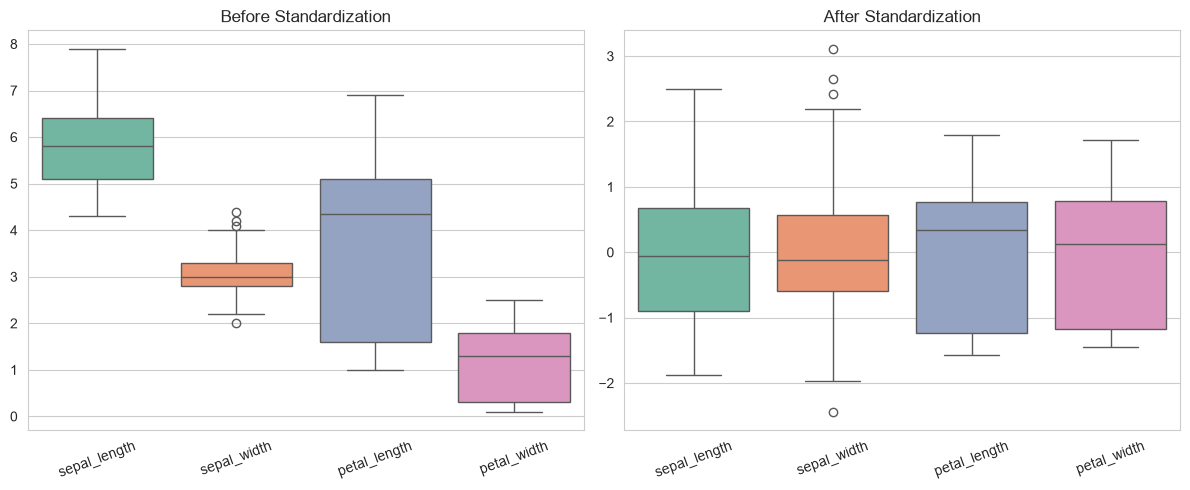

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df[numeric_cols], ax=axes[0], palette="Set2")
axes[0].set_title("Before Standardization")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_standardized, ax=axes[1], palette="Set2")
axes[1].set_title("After Standardization")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("../outputs/day6_transformation_comparison.png", dpi=120)
plt.show()

## Summary of Unit II Findings

1. **Univariate analysis:** Histograms and density plots revealed petal
   measurements are bimodal (driven by species separation), a shape that
   boxplots alone hid — violin plots recovered it.
2. **Bivariate analysis:** Petal length and petal width are very strongly
   correlated (~0.96); grouped bar plots showed clear mean differences
   across species for every measurement.
3. **Multivariate analysis:** Pair plots and the correlation heatmap
   confirmed setosa is a fully separate cluster, while versicolor and
   virginica overlap more, especially on sepal measurements.
4. **PCA:** The first two principal components captured well over 95% of
   total variance, meaning the 4D dataset can be represented in 2D with
   minimal information loss while preserving cluster structure.
5. **Multicollinearity:** petal_length and petal_width showed high VIF,
   indicating redundancy — a candidate for dropping one, or relying on
   PCA components instead of raw features in downstream modeling.
6. **Data transformation:** Standardization brought all features onto a
   comparable scale; one-hot encoding is the safer choice for the nominal
   `species` variable compared to label encoding, since species has no
   natural order.

**Conclusion:** This project demonstrates how univariate, bivariate, and
multivariate EDA techniques, combined with dimensionality reduction and
multicollinearity checks, build a complete picture of a dataset's structure
and prepare it appropriately for modeling.